In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Árboles de decisión

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [3]:
# Cargamos el dataset
X_train = pd.read_csv("../datasets/X_train.csv")
X_test = pd.read_csv("../datasets/X_test.csv")
y_train = pd.read_csv("../datasets/y_train.csv")
y_test = pd.read_csv("../datasets/y_test.csv")


In [36]:
X_train.dropna(subset=['gender'], inplace=True)
y_train = y_train.loc[X_train.index]

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3577, 15), (1533, 15), (3577, 1), (1533, 1))

In [35]:
X_train.isnull().sum()

age                               0
avg_glucose_level                 0
bmi                               0
hypertension                      0
heart_disease                     0
gender                            1
ever_married                      0
Residence_type                    0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [5]:
y_train.value_counts()

stroke
0         3403
1          174
Name: count, dtype: int64

Las clases están muy desbalanceadas, entonces vamos a usar DecisionTreeClassifier con class_weight = 'balanced', de este modo utiliza los valores de y para ajustar automáticamente los pesos inversamente proporcionales a las frecuencias de clase en los datos de entrada como n_samples / (n_classes * np.bincount(y))

Ahora vamos a aplicar el modelo, primero llamamos al modelo de [árbol de clasificación](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', splitter='best', class_weight='balanced',
                                        max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                        random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

In [7]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos ver a nuestro arbol para entender que hizo usando export_graphviz

In [8]:
export_graphviz(classification, out_file = "arbol_clasificacion.dot",
                feature_names=X_train.columns,
                class_names=["No tiene enfermedad cardiaca", "Tiene enfermedad cardiaca"],
                rounded=True,
                filled=True)

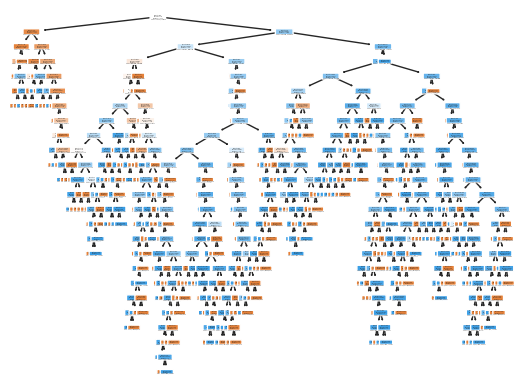

In [9]:
from sklearn.tree import plot_tree
plot_tree(classification, filled=True, rounded=True);

Midamos como este modelo performa usando el F1-score:

In [ ]:
y_pred_train = classification.predict(X_train)
y_pred = classification.predict(X_test)

f1_train = f1_score(y_train, y_pred_train)
f1 = f1_score(y_test, y_pred)

print(f"F1-score de entreamiento fue: {f1_train}")
print(f"F1-score de testeo fue: {f1}")

F1-score de entreamiento fue: 1.0
F1-score de testeo fue: 0.08163265306122448


F1-score fue muy bajo para el testeo, lo cual muestra que el modelo no es muy robusto

In [11]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos hacer una búsqueda de hiper-parámetros pero buscando con otros parámetros del modelo, usando optuna:

In [12]:
import optuna 

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    classifier = DecisionTreeClassifier(criterion=criterion, splitter='best', class_weight=class_weight,
                                        max_depth=max_depth, min_samples_split=min_samples_split, 
                                        min_samples_leaf=min_samples_leaf, random_state=42)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    
    return score.mean()

In [13]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [14]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.13605984303378812
Trial 1 achieved value: 0.1936528865429572 with  29.7403% improvement
Trial 3 achieved value: 0.20171679580223806 with  3.9976% improvement
Trial 17 achieved value: 0.2081761421508897 with  3.1028% improvement
Trial 20 achieved value: 0.2113310926451542 with  1.4929% improvement
Trial 475 achieved value: 0.21278574266698067 with  0.6836% improvement
Trial 558 achieved value: 0.21356726467224402 with  0.3659% improvement
Trial 588 achieved value: 0.2146986442351329 with  0.5270% improvement
Trial 705 achieved value: 0.21772746192046494 with  1.3911% improvement


In [15]:
# Obtenemos los mejores hiperparámetros encontrados
best_params = study.best_params
best_params

{'max_depth': 9,
 'criterion': 'gini',
 'class_weight': 'balanced',
 'min_samples_split': 6,
 'min_samples_leaf': 1}

In [16]:
# Creamos el arbol
classification = DecisionTreeClassifier(**best_params, random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=9,
                       min_samples_split=6, random_state=42)

In [17]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

y_pred = classification.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"La exactitud de clasificación es: {accuracy}")
print(f"F1-score de testeo fue: {f1}")
print(f"Precisión de testeo fue: {precision}")
print(f"Recall de testeo fue: {recall}")

La exactitud de clasificación es: 0.7938682322243966
F1-score de testeo fue: 0.22167487684729065
Precisión de testeo fue: 0.13595166163141995
Recall de testeo fue: 0.6


In [41]:
export_graphviz(classification, out_file="arbol_clasificacion_level7.dot",
                feature_names=df_heart.columns[:-1],
                class_names=["No tiene enfermedad cardiaca", "Tiene enfermedad cardiaca"],
                rounded=True,
                filled=True)

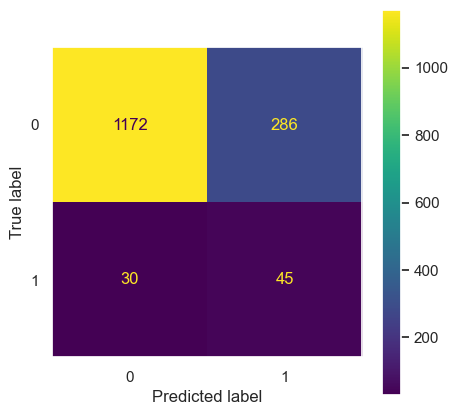

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=classification.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classification.classes_)

fig, ax = plt.subplots(figsize=(5,5))
ax.grid(False)
disp.plot(ax=ax);

Veamos la curva ROC:

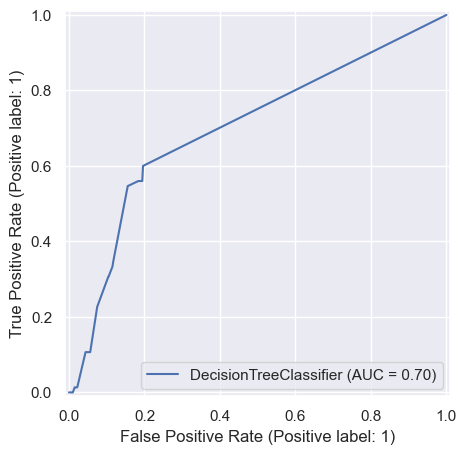

In [19]:
from sklearn.metrics import RocCurveDisplay
    
fig, ax = plt.subplots(figsize=(5,5))
svc_disp = RocCurveDisplay.from_estimator(classification, X_test, y_test, ax=ax)

plt.show();

Comparemos con nuestro modelo de SVC:

| Modelo                   | Exactitud  | F1   | Precisión | Recuperación |
|--------------------------|------------|------|-----------|--------------|
| Arbol de clasificación   | 0.90       | 0.13 | 0.12      | 0.14         |
| SVC                      | XXXx       | xxxx | xxxx      | xxxx         |

----
Veamos un modelo de dos dimensiones para ver como es la región de clasificación de un modelo

In [20]:
X_train.columns

Index(['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease',
       'gender', 'ever_married', 'Residence_type', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='object')

In [86]:
X = X_train.loc[:, ['smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes', 'heart_disease', 'age']].values
y = y_train.values

# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Y entrenamos
classification.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Bagging

In [28]:
from sklearn.ensemble import BaggingClassifier

# Creamos un Bagging con 20 estimadores (20 árboles)
bagging_classifier = BaggingClassifier(estimator=classification, n_estimators=20, random_state=42, n_jobs=-1)
bagging_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_bag = bagging_classifier.predict(X_test)

metrics_bag = {
    "name": "Bagging",
    "Recall": recall_score(y_test, y_pred_bag),
    "Precision": precision_score(y_test, y_pred_bag),
    "Accuracy": accuracy_score(y_test, y_pred_bag),    
    "F1": f1_score(y_test, y_pred_bag, average='macro')
}

metrics_bag

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'name': 'Bagging',
 'Recall': 0.48,
 'Precision': 0.19889502762430938,
 'Accuracy': 0.8799739073711677,
 'F1': 0.6078847864768684}

### Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Creamos un bosque aleatorio por defecto (100 árboles)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_rf = rf_classifier.predict(X_test)

metrics_rf = {
    "name": "Random Forest",
    "Recall": recall_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),    
    "F1": f1_score(y_test, y_pred_rf, average='macro')
}

metrics_rf

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'name': 'Random Forest',
 'Recall': 0.013333333333333334,
 'Precision': 0.25,
 'Accuracy': 0.9497716894977168,
 'F1': 0.49976904137337747}

### Boosting

In [39]:
from sklearn.ensemble import AdaBoostClassifier

# Inicializamos el árbol (weak learner)
base_estimator = DecisionTreeClassifier(max_depth=6)

# Configuramos también la cantidad y la constante de aprendizaje
adaboost_classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=500, random_state=42, learning_rate=0.01)
adaboost_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_ada = adaboost_classifier.predict(X_test)

metrics_ada = {
    "name": "AdaBoost",
    "Recall": recall_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Accuracy": accuracy_score(y_test, y_pred_ada),    
    "F1": f1_score(y_test, y_pred_ada, average='macro')
}

metrics_ada

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'name': 'AdaBoost',
 'Recall': 0.0,
 'Precision': 0.0,
 'Accuracy': 0.9504240052185258,
 'F1': 0.4872909698996655}